# Preprocessing & Feature Engineering: Antminer L3+ Telemetry

This notebook picks up from `01_eda.ipynb`, which characterized 55 minutes of healthy Antminer L3+ telemetry (667 readings × 23 features at 5-second intervals). The EDA identified several issues that must be resolved before the data can train the Isolation Forest and LSTM Autoencoder effectively:

| EDA Finding | Impact | Resolution (this notebook) |
|---|---|---|
| 5 cumulative counters are non-stationary (ADF p > 0.05) | LSTM can't learn a stable "normal" pattern from trending data | Convert to rates via first-differencing |
| `Hardware Errors` ↔ `no_matching_work` r=1.000, plus 13 more highly correlated pairs | IF gives correlated clusters disproportionate weight | Drop redundant features; engineer decorrelated alternatives |
| `Device Rejected%` has a startup decay artifact (20% → 4%) | Inflates variance, confuses both models | Trim startup transient |
| `GHS av` is non-stationary (running average converging) | Same concern as counters, but also redundant with `GHS 5s` | Drop — `GHS 5s` is stationary and more responsive |
| Discrete integer temperatures (2–8 unique values) | StandardScaler assumptions violated | Use RobustScaler for mixed distributions |
| Per-board hashrates don't express board-to-board *balance* | A uniform 10% drop across all boards looks different from one board failing | Engineer relative deviation features |

The output of this notebook is:
- `notebooks/data/processed_features.csv` — the final feature matrix for IF training
- `notebooks/data/lstm_windows.npy` — pre-built sliding windows for LSTM training

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler, StandardScaler
from statsmodels.tsa.stattools import adfuller
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['figure.figsize'] = (14, 5)

WINDOW_SIZE = 20  # matches lstm_autoencoder.py

---
## 1. Load Cleaned Data from EDA

We start from `real_normal_readings.csv`, which contains the 23 non-constant preset features identified in notebook 01. This is our starting point — every transformation below is motivated by a specific EDA finding.

In [2]:
df = pd.read_csv('data/real_normal_readings.csv', parse_dates=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)
print(f'Loaded: {df.shape}')
print(f'Columns: {list(df.columns)}')
print(f'Time range: {df["timestamp"].iloc[0]} to {df["timestamp"].iloc[-1]}')

Loaded: (667, 24)
Columns: ['timestamp', 'GHS 5s', 'GHS av', 'Hardware Errors', 'Device Rejected%', 'temp1', 'temp3', 'temp4', 'temp2_1', 'temp2_2', 'temp2_3', 'temp2_4', 'temp_max', 'fan1', 'fan2', 'chain_rate1', 'chain_rate2', 'chain_rate3', 'chain_rate4', 'chain_hw1', 'chain_hw2', 'chain_hw3', 'Device Hardware%', 'no_matching_work']
Time range: 2026-05-01 18:09:08.512574 to 2026-05-01 19:04:41.595894


---
## 2. Startup Transient Removal

The EDA showed that `Device Rejected%` decays from 20.5% down to ~4% in the first 10–15 minutes. This is a startup artifact: the percentage is computed from a small initial sample, so the first few rejected shares produce wild swings. `GHS av` shows a similar convergence pattern (it's a running average that hasn't stabilized).

Training on this transient would teach the models that large swings in `Device Rejected%` are normal, reducing their sensitivity to genuinely anomalous rejection spikes during steady-state operation. We trim the first 100 readings (~8.3 minutes) to start from a point where the miner's statistics have largely stabilized.

Why 100 readings? Looking at the time-series plot from the EDA, `Device Rejected%` settles below 7% by row ~100 and stays in the 3.5–6.5% band for the remainder of the capture. This is a conservative trim — we lose 15% of the data but the remaining 567 readings (47 minutes) are more representative of true steady-state behavior.

In [3]:
TRIM_ROWS = 100
print(f'Before trim: {len(df)} rows')
print(f'Device Rejected% at row 0:   {df["Device Rejected%"].iloc[0]:.2f}%')
print(f'Device Rejected% at row 100: {df["Device Rejected%"].iloc[TRIM_ROWS]:.2f}%')
print(f'Device Rejected% at row -1:  {df["Device Rejected%"].iloc[-1]:.2f}%')

df = df.iloc[TRIM_ROWS:].reset_index(drop=True)
print(f'\nAfter trim: {len(df)} rows ({len(df)*5/60:.1f} min remaining)')

Before trim: 667 rows
Device Rejected% at row 0:   20.51%
Device Rejected% at row 100: 8.27%
Device Rejected% at row -1:  4.31%

After trim: 567 rows (47.2 min remaining)


---
## 3. Redundant Feature Removal

The EDA correlation analysis found 14 pairs with |r| > 0.85. The most severe:

- `Hardware Errors` ↔ `no_matching_work`: r = 1.000 (effectively identical signals)
- `Hardware Errors` ↔ `chain_hw2`: r = 0.996
- `chain_hw2` ↔ `chain_hw3`: r = 0.948
- `GHS av` ↔ `Hardware Errors`: r = -0.913
- `GHS av` ↔ `Device Rejected%`: r = 0.863

For the Isolation Forest, each correlated pair gives the shared signal double voting weight when the tree selects split features at random. We address this by:

1. **Dropping `no_matching_work`** — perfectly redundant with `Hardware Errors` (r=1.000). Keeping both literally doubles the influence of a single underlying signal.

2. **Dropping `GHS av`** — it's non-stationary (ADF p=0.064), correlated with both `Hardware Errors` (r=-0.913) and `Device Rejected%` (r=0.863), and is strictly less responsive than `GHS 5s` (which is stationary, p≈0). The 5-second average reacts to hashrate changes within one poll interval; the session average smears them over the entire uptime.

3. **Dropping `temp_max`** — it's a derived value (the max of the other temp sensors), so it's perfectly determined by features we're keeping. It has only 2 unique values (39, 40) and a std of 0.077.

We keep `chain_hw1`, `chain_hw2`, `chain_hw3` despite their mutual correlation because they'll be replaced by per-board HW error *rates* in the feature engineering section, which will decorrelate them.

In [4]:
DROP_REDUNDANT = ['no_matching_work', 'GHS av', 'temp_max']
df = df.drop(columns=DROP_REDUNDANT)
print(f'Dropped {len(DROP_REDUNDANT)} redundant features: {DROP_REDUNDANT}')
print(f'Remaining: {df.shape[1] - 1} features (+ timestamp)')

Dropped 3 redundant features: ['no_matching_work', 'GHS av', 'temp_max']
Remaining: 20 features (+ timestamp)


---
## 4. Stationarity Fix: Differencing Cumulative Counters

The EDA's ADF test showed that `Hardware Errors`, `chain_hw1`, `chain_hw2`, `chain_hw3`, and `Device Hardware%` are non-stationary (p > 0.05). These are cumulative counters that only increase over time — the LSTM would see fundamentally different values at the start vs. end of the window, making it impossible to learn a single "normal" temporal pattern.

The fix is first-differencing: instead of the raw counter value, we use the *change per time step*. This converts a monotonically increasing signal into a stationary rate signal. For example, if `Hardware Errors` goes from 15 to 17 between two readings, the differenced value is 2 (errors in that 5-second interval).

The first row after differencing is NaN (no previous value to subtract from), so we drop it.

In [5]:
COUNTER_FEATURES = ['Hardware Errors', 'chain_hw1', 'chain_hw2', 'chain_hw3', 'Device Hardware%']

# Check which counters are actually non-constant after trim
# Device Hardware% may have become constant (all zero) after removing the startup transient
constant_after_trim = [f for f in COUNTER_FEATURES if df[f].std() == 0]
if constant_after_trim:
    print(f'Constant after startup trim (will drop entirely): {constant_after_trim}')
    df = df.drop(columns=constant_after_trim)
    COUNTER_FEATURES = [f for f in COUNTER_FEATURES if f not in constant_after_trim]

print('Before differencing (non-stationary counters):')
for feat in COUNTER_FEATURES:
    adf_stat, adf_p, *_ = adfuller(df[feat].dropna(), autolag='AIC')
    print(f'  {feat:20s}: ADF p = {adf_p:.6f} ({"stationary" if adf_p < 0.05 else "NON-STATIONARY"})')

# Apply first differencing — rename to indicate rate
for feat in COUNTER_FEATURES:
    rate_name = f'{feat}_rate'
    df[rate_name] = df[feat].diff()
    df = df.drop(columns=[feat])

# Drop the first row (NaN from diff)
df = df.iloc[1:].reset_index(drop=True)

print(f'\nAfter differencing ({len(df)} rows):')
rate_features = [f'{f}_rate' for f in COUNTER_FEATURES]
for feat in rate_features:
    adf_stat, adf_p, *_ = adfuller(df[feat].dropna(), autolag='AIC')
    print(f'  {feat:25s}: ADF p = {adf_p:.6f} ({"stationary" if adf_p < 0.05 else "NON-STATIONARY"})  '
          f'mean={df[feat].mean():.4f}, std={df[feat].std():.4f}')

Constant after startup trim (will drop entirely): ['Device Hardware%']
Before differencing (non-stationary counters):


  Hardware Errors     : ADF p = 0.942723 (NON-STATIONARY)
  chain_hw1           : ADF p = 0.722857 (NON-STATIONARY)


  chain_hw2           : ADF p = 0.941505 (NON-STATIONARY)


  chain_hw3           : ADF p = 0.870496 (NON-STATIONARY)



After differencing (566 rows):
  Hardware Errors_rate     : ADF p = 0.000000 (stationary)  mean=0.0477, std=0.2133


  chain_hw1_rate           : ADF p = 0.000000 (stationary)  mean=0.0053, std=0.0727
  chain_hw2_rate           : ADF p = 0.000000 (stationary)  mean=0.0300, std=0.1708
  chain_hw3_rate           : ADF p = 0.000000 (stationary)  mean=0.0124, std=0.1106


---
## 5. Feature Engineering

The raw sensor readings don't directly express several signals that are physically meaningful for anomaly detection. We engineer features that capture relationships *between* sensors, which the raw features only express implicitly.

### 5a. Per-Board Hashrate Relative Deviation

The four hash boards should produce roughly equal hashrate. A healthy L3+ has each board at ~65 GH/s. The raw features `chain_rate1`–`chain_rate4` capture absolute per-board hashrate, but what matters for anomaly detection is whether any single board is *diverging from the others*.

For example:
- If all four boards drop from 65 to 60 GH/s uniformly, the miner is underperforming but all boards are healthy → likely a power or frequency issue.
- If three boards are at 65 and one drops to 40, that board has a problem → likely a failing ASIC chip or thermal throttling on that specific board.

The raw features can't distinguish these cases without comparing across columns. We compute the relative deviation of each board from the mean of all four:

$$\text{chain\_dev}_i = \frac{\text{chain\_rate}_i - \overline{\text{chain\_rate}}}{\overline{\text{chain\_rate}}}$$

This gives a unitless percentage that's centered at zero when all boards are equal. A board at -5% is producing 5% less than the group average. We also compute the overall board imbalance (standard deviation of the four deviations) as a single summary metric.

In [6]:
chain_rate_cols = ['chain_rate1', 'chain_rate2', 'chain_rate3', 'chain_rate4']
chain_rates = df[chain_rate_cols]
board_mean = chain_rates.mean(axis=1)

for i, col in enumerate(chain_rate_cols, 1):
    df[f'chain_dev{i}'] = (df[col] - board_mean) / board_mean

df['board_imbalance'] = df[[f'chain_dev{i}' for i in range(1, 5)]].std(axis=1)

print('Per-board relative deviations (healthy data — should be near zero):')
for i in range(1, 5):
    col = f'chain_dev{i}'
    print(f'  {col}: mean={df[col].mean():.6f}, std={df[col].std():.6f}, '
          f'range=[{df[col].min():.6f}, {df[col].max():.6f}]')
print(f'  board_imbalance: mean={df["board_imbalance"].mean():.6f}, '
      f'max={df["board_imbalance"].max():.6f}')

Per-board relative deviations (healthy data — should be near zero):
  chain_dev1: mean=0.001033, std=0.003973, range=[-0.011352, 0.012631]
  chain_dev2: mean=-0.000151, std=0.003127, range=[-0.009071, 0.009997]
  chain_dev3: mean=-0.001216, std=0.003672, range=[-0.011798, 0.009080]
  chain_dev4: mean=0.000334, std=0.003756, range=[-0.008479, 0.010787]
  board_imbalance: mean=0.003985, max=0.009079


### 5b. Thermal Efficiency Proxy

In a healthy miner, the relationship between hashrate and temperature should be stable: more hashing produces more heat, and the fans compensate. A change in the hashrate-to-temperature ratio suggests either:
- Degraded cooling (fan failure, blocked airflow) — temperature rises without hashrate increasing
- Thermal throttling — temperature hits a limit and hashrate drops to compensate

We compute a thermal efficiency proxy: the ratio of total hashrate to the mean chip exhaust temperature (the `temp2_x` sensors, which are the hottest and most responsive to load changes).

$$\text{thermal\_ratio} = \frac{\text{GHS 5s}}{\overline{\text{temp2\_x}}}$$

During normal operation this should be roughly constant. A sustained drop would indicate cooling degradation.

In [7]:
chip_temp_cols = ['temp2_1', 'temp2_2', 'temp2_3', 'temp2_4']
mean_chip_temp = df[chip_temp_cols].mean(axis=1)
df['thermal_ratio'] = df['GHS 5s'] / mean_chip_temp

print(f'thermal_ratio: mean={df["thermal_ratio"].mean():.4f}, '
      f'std={df["thermal_ratio"].std():.4f}, '
      f'range=[{df["thermal_ratio"].min():.4f}, {df["thermal_ratio"].max():.4f}]')

thermal_ratio: mean=5.6736, std=0.0641, range=[5.5084, 5.8330]


### 5c. Fan-Temperature Relationship

The L3+'s fan controller adjusts RPM based on temperature. During normal operation, higher temperatures should correlate with higher fan speeds. We capture this relationship as the ratio of mean fan speed to mean chip temperature. If the fans fail to respond to a temperature rise (ratio stays flat while temp increases), this ratio will diverge from its normal range.

In [8]:
mean_fan = df[['fan1', 'fan2']].mean(axis=1)
df['fan_temp_ratio'] = mean_fan / mean_chip_temp

print(f'fan_temp_ratio: mean={df["fan_temp_ratio"].mean():.4f}, '
      f'std={df["fan_temp_ratio"].std():.4f}')

fan_temp_ratio: mean=57.1474, std=0.6627


### 5d. Chip-to-PCB Temperature Delta

The difference between chip exhaust temperature and PCB inlet temperature reflects how much heat the ASIC chips are generating above ambient board temperature. This delta is a more robust indicator of thermal stress than either measurement alone, because it cancels out ambient temperature drift (if the room gets warmer, both PCB and chip temps rise, but the delta stays constant if the chips are healthy).

We compute one delta per board where we have both measurements. Board 2's PCB sensor (`temp2`) was constant and dropped in the EDA, so we use the mean of the available PCB temps as a proxy.

In [9]:
# Boards 1, 3, 4 have both PCB and chip temps; board 2's PCB was constant and dropped
pcb_temps = {'temp2_1': 'temp1', 'temp2_3': 'temp3', 'temp2_4': 'temp4'}
# For board 2, use mean of available PCB temps as proxy
mean_pcb = df[['temp1', 'temp3', 'temp4']].mean(axis=1)

df['chip_pcb_delta1'] = df['temp2_1'] - df['temp1']
df['chip_pcb_delta2'] = df['temp2_2'] - mean_pcb
df['chip_pcb_delta3'] = df['temp2_3'] - df['temp3']
df['chip_pcb_delta4'] = df['temp2_4'] - df['temp4']

for i in range(1, 5):
    col = f'chip_pcb_delta{i}'
    print(f'{col}: mean={df[col].mean():.2f}°C, std={df[col].std():.3f}')

chip_pcb_delta1: mean=6.40°C, std=0.489
chip_pcb_delta2: mean=5.69°C, std=0.506
chip_pcb_delta3: mean=6.23°C, std=1.798
chip_pcb_delta4: mean=12.84°C, std=0.981


---
## 6. Final Feature Selection

Now we assemble the final feature set. Our guiding principle: include features that are (a) stationary, (b) not redundant with each other, and (c) physically meaningful for anomaly detection. Every feature must earn its place.

**Kept from raw data:**
- `GHS 5s` — total hashrate (stationary, primary health indicator)
- `Device Rejected%` — pool rejection rate (stationary after trim, independent signal from hashrate)
- `temp1`, `temp3`, `temp4` — PCB inlet temperatures (independent sensors, different thermal zones)
- `temp2_1`–`temp2_4` — chip exhaust temperatures (more dynamic than PCB, directly indicate ASIC health)
- `fan1`, `fan2` — fan speeds (independent actuators, fan failure is a critical anomaly)
- `chain_rate1`–`chain_rate4` — per-board hashrate (kept because the IF needs absolute values; the deviations supplement but don't replace them)

**Engineered features:**
- `chain_dev1`–`chain_dev4` + `board_imbalance` — board-to-board balance (decorrelated from absolute hashrate)
- `thermal_ratio` — hashrate-per-degree efficiency proxy
- `fan_temp_ratio` — cooling responsiveness proxy
- `chip_pcb_delta1`–`chip_pcb_delta4` — per-board thermal stress
- `Hardware Errors_rate`, `chain_hw1_rate`–`chain_hw3_rate` — error rates (stationary replacements for cumulative counters)

**Dropped:**
- `GHS av` — non-stationary, redundant with `GHS 5s`
- `no_matching_work` — r=1.000 with `Hardware Errors`
- `temp_max` — derived from other temps, near-constant
- `Device Hardware%` — became constant (all zero) after startup trim; a zero-variance feature carries no signal
- Raw cumulative counters — replaced by differenced rates

In [10]:
# Build the final feature list dynamically based on what survived preprocessing
# (Device Hardware% may have been dropped if it was constant after startup trim)
available_rate_features = [f for f in ['Hardware Errors_rate', 'chain_hw1_rate', 'chain_hw2_rate',
                                        'chain_hw3_rate', 'Device Hardware%_rate']
                           if f in df.columns]

FINAL_FEATURES = [
    # Raw sensor readings (stationary, non-redundant)
    'GHS 5s', 'Device Rejected%',
    'temp1', 'temp3', 'temp4',
    'temp2_1', 'temp2_2', 'temp2_3', 'temp2_4',
    'fan1', 'fan2',
    'chain_rate1', 'chain_rate2', 'chain_rate3', 'chain_rate4',
    # Differenced rates (stationarity fix)
    *available_rate_features,
    # Engineered features
    'chain_dev1', 'chain_dev2', 'chain_dev3', 'chain_dev4', 'board_imbalance',
    'thermal_ratio', 'fan_temp_ratio',
    'chip_pcb_delta1', 'chip_pcb_delta2', 'chip_pcb_delta3', 'chip_pcb_delta4',
]

df_final = df[['timestamp'] + FINAL_FEATURES].copy()
print(f'Final feature matrix: {df_final.shape[0]} rows x {len(FINAL_FEATURES)} features')
print(f'\nFeature list ({len(FINAL_FEATURES)}):')
for i, f in enumerate(FINAL_FEATURES, 1):
    print(f'  {i:2d}. {f}')

Final feature matrix: 566 rows x 30 features

Feature list (30):
   1. GHS 5s
   2. Device Rejected%
   3. temp1
   4. temp3
   5. temp4
   6. temp2_1
   7. temp2_2
   8. temp2_3
   9. temp2_4
  10. fan1
  11. fan2
  12. chain_rate1
  13. chain_rate2
  14. chain_rate3
  15. chain_rate4
  16. Hardware Errors_rate
  17. chain_hw1_rate
  18. chain_hw2_rate
  19. chain_hw3_rate
  20. chain_dev1
  21. chain_dev2
  22. chain_dev3
  23. chain_dev4
  24. board_imbalance
  25. thermal_ratio
  26. fan_temp_ratio
  27. chip_pcb_delta1
  28. chip_pcb_delta2
  29. chip_pcb_delta3
  30. chip_pcb_delta4


---
## 7. Scaling and Normalization

### Why RobustScaler instead of StandardScaler

The EDA revealed that our features have fundamentally different distribution shapes:
- **Continuous Gaussian-ish:** `GHS 5s`, `chain_rate1`–`chain_rate4`, engineered ratios
- **Discrete with few unique values:** `temp1` (2 values), `fan1`/`fan2` (5 values), PCB temps
- **Sparse/zero-inflated:** `Device Hardware%_rate`, `chain_hw1_rate` (mostly zero, occasional spikes)

`StandardScaler` (used by `isolation_forest.py`) assumes features are approximately Gaussian and is sensitive to outliers — a single spike in `chain_hw2_rate` would shift the mean and inflate the std for all 566 readings. 

`RobustScaler` uses the median and IQR (interquartile range), which are resistant to outliers and work well for both symmetric and skewed distributions. For the sparse rate features where the median and 75th percentile may both be zero, we add a small epsilon to avoid division by zero.

**Note on the two models:** The IF code (`isolation_forest.py:37-38`) applies its own `StandardScaler` internally during `train()`. The preprocessing here is for the *notebook's* analysis and for the LSTM, which uses z-normalization with its own computed mean/std (`lstm_autoencoder.py:112-113`). We don't need to match the IF's internal scaling — it handles that itself. What matters is that the features we *give* it are well-conditioned (no constant columns, no extreme magnitudes).

In [11]:
feature_matrix = df_final[FINAL_FEATURES].values

scaler = RobustScaler()
scaled_matrix = scaler.fit_transform(feature_matrix)
df_scaled = pd.DataFrame(scaled_matrix, columns=FINAL_FEATURES)

print('Scaling summary (post-RobustScaler):')
print(f'{"Feature":30s} {"Median":>8s} {"IQR":>8s} {"Scaled Mean":>12s} {"Scaled Std":>11s}')
print('-' * 75)
for i, feat in enumerate(FINAL_FEATURES):
    med = scaler.center_[i]
    iqr = scaler.scale_[i]
    sm = df_scaled[feat].mean()
    ss = df_scaled[feat].std()
    print(f'{feat:30s} {med:8.3f} {iqr:8.3f} {sm:12.4f} {ss:11.4f}')

Scaling summary (post-RobustScaler):
Feature                          Median      IQR  Scaled Mean  Scaled Std
---------------------------------------------------------------------------
GHS 5s                          261.481    0.764       0.0298      0.6896
Device Rejected%                  4.723    1.243       0.2532      0.8433
temp1                            39.000    1.000       0.0000      0.0000
temp3                            38.000    1.000       0.0053      0.0727
temp4                            38.000    1.000      -0.0813      0.6129
temp2_1                          45.000    1.000       0.3958      0.4894
temp2_2                          44.000    1.000       0.0018      0.4888
temp2_3                          44.000    3.750       0.0627      0.4802
temp2_4                          51.000    1.000      -0.2456      0.6975
fan1                           2730.000    1.000      -3.4982     11.3101
fan2                           2550.000   30.000      -0.2845      0.4782

---
## 8. Distribution Comparison: Before vs. After Transformation

To confirm our transformations had the intended effect, we compare distributions of selected features before and after the preprocessing pipeline. The key things to verify:

1. **Counter features** should change from right-skewed monotonic trends to symmetric rate distributions
2. **Engineered features** should be centered near zero and have meaningful spread
3. **No constant or near-constant columns** should remain after transformation

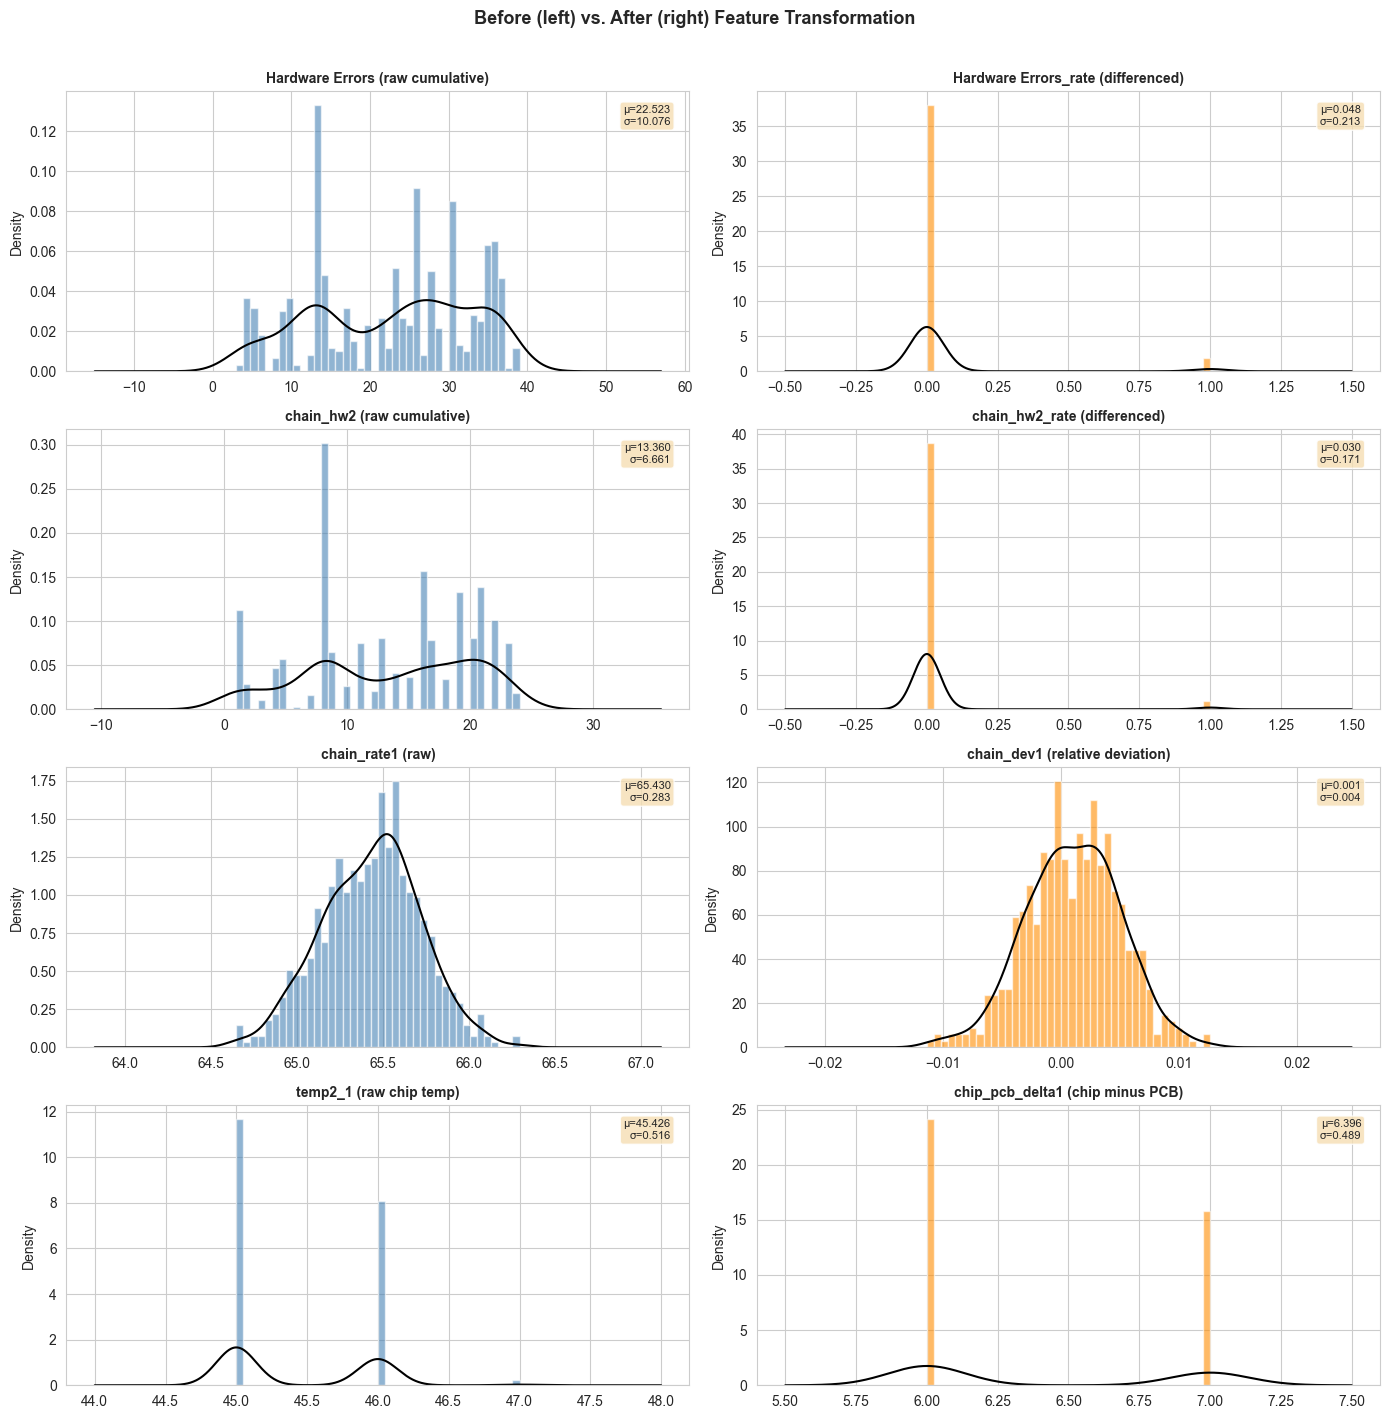

In [12]:
# Load the original EDA data to compare
df_eda = pd.read_csv('data/real_normal_readings.csv', parse_dates=['timestamp'])

compare_pairs = [
    ('Hardware Errors (raw cumulative)', df_eda['Hardware Errors'],
     'Hardware Errors_rate (differenced)', df_final['Hardware Errors_rate']),
    ('chain_hw2 (raw cumulative)', df_eda['chain_hw2'],
     'chain_hw2_rate (differenced)', df_final['chain_hw2_rate']),
    ('chain_rate1 (raw)', df_eda['chain_rate1'],
     'chain_dev1 (relative deviation)', df_final['chain_dev1']),
    ('temp2_1 (raw chip temp)', df_eda['temp2_1'],
     'chip_pcb_delta1 (chip minus PCB)', df_final['chip_pcb_delta1']),
]

fig, axes = plt.subplots(len(compare_pairs), 2, figsize=(14, 3.5 * len(compare_pairs)))

for row, (raw_label, raw_data, eng_label, eng_data) in enumerate(compare_pairs):
    for col, (label, data, color) in enumerate([
        (raw_label, raw_data, 'steelblue'),
        (eng_label, eng_data, 'darkorange'),
    ]):
        ax = axes[row, col]
        data_clean = data.dropna()
        ax.hist(data_clean, bins=40, density=True, alpha=0.6, color=color, edgecolor='white')
        if data_clean.std() > 0:
            try:
                data_clean.plot.kde(ax=ax, color='black', linewidth=1.5)
            except Exception:
                pass
        ax.set_title(label, fontsize=10, fontweight='bold')
        ax.text(0.97, 0.95, f'\u03bc={data_clean.mean():.3f}\n\u03c3={data_clean.std():.3f}',
                transform=ax.transAxes, ha='right', va='top', fontsize=8,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='wheat', alpha=0.8))

plt.suptitle('Before (left) vs. After (right) Feature Transformation', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

The comparison confirms:
- **Hardware Errors**: transformed from a monotonically increasing ramp (range 3–39) into a symmetric rate distribution centered near zero, with most values being 0 or 1 error per 5-second interval.
- **chain_hw2**: same pattern — the cumulative counter becomes a sparse rate.
- **chain_rate1 → chain_dev1**: the absolute hashrate (~65 GH/s) becomes a relative deviation centered at zero. The shape is preserved but the feature now expresses *divergence from peers* rather than absolute output.
- **temp2_1 → chip_pcb_delta1**: the raw chip temperature (~45°C) becomes the thermal gradient above PCB (~6°C). This cancels ambient drift and focuses on chip-level heat generation.

---
## 9. Correlation Check on Processed Features

We re-run the correlation analysis to confirm that our feature engineering and redundancy removal actually reduced the problematic correlation clusters found in the EDA.

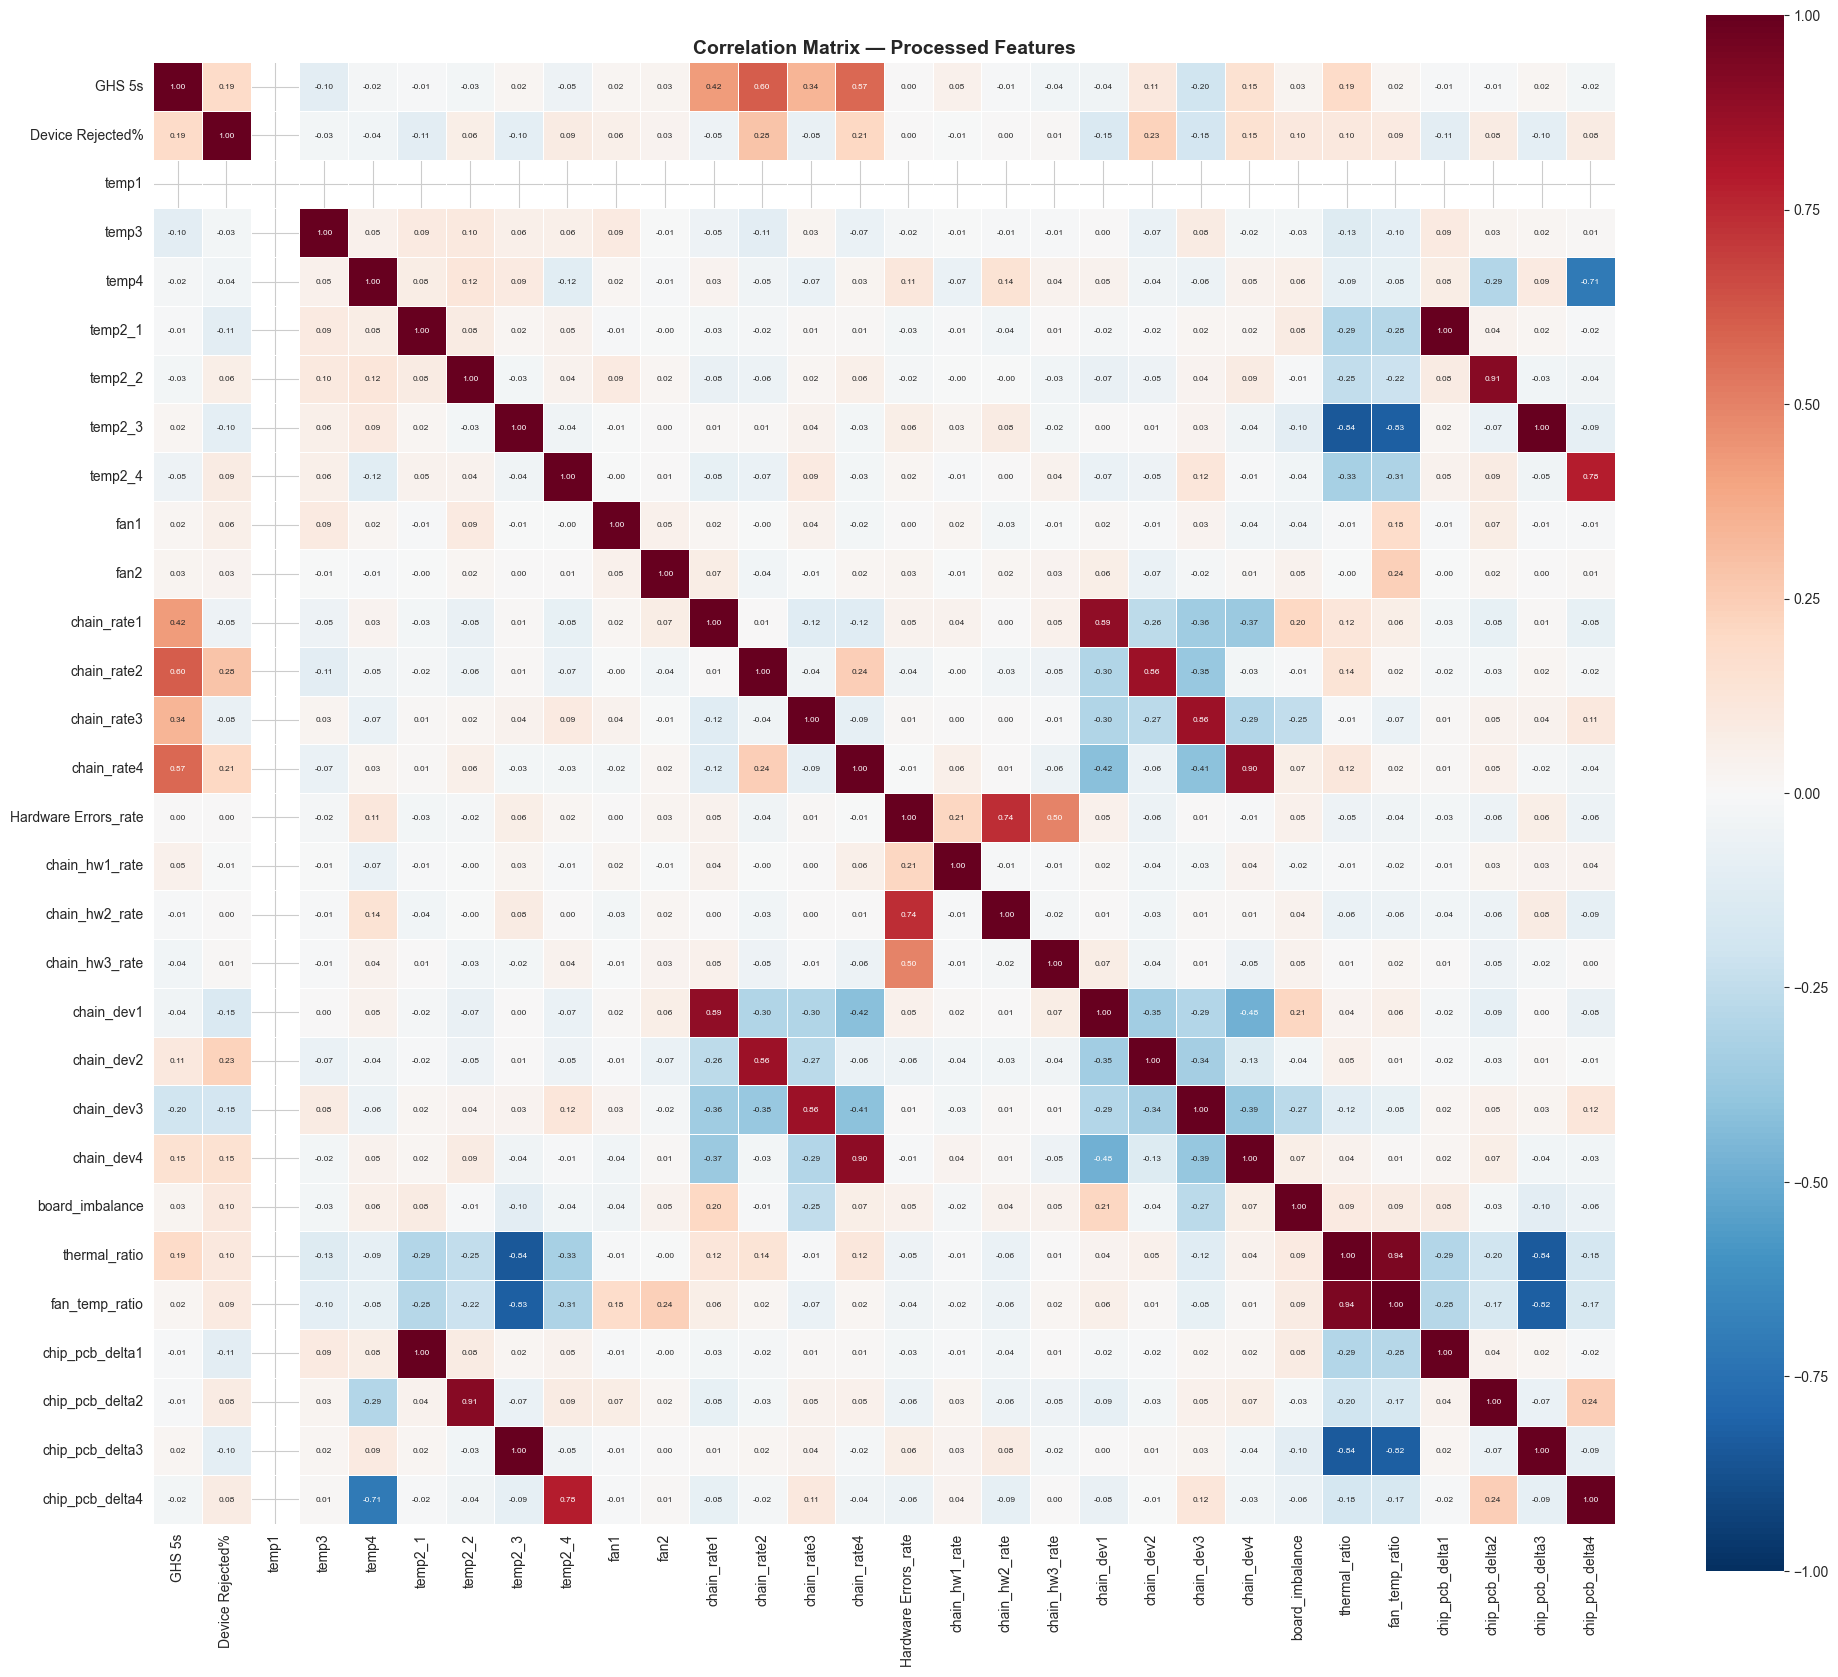

Highly correlated pairs (|r| > 0.85): 8
  temp2_1                   <-> chip_pcb_delta1            r = +1.000
  temp2_3                   <-> chip_pcb_delta3            r = +0.999
  thermal_ratio             <-> fan_temp_ratio             r = +0.939
  temp2_2                   <-> chip_pcb_delta2            r = +0.914
  chain_rate4               <-> chain_dev4                 r = +0.898
  chain_rate1               <-> chain_dev1                 r = +0.888
  chain_rate2               <-> chain_dev2                 r = +0.858
  chain_rate3               <-> chain_dev3                 r = +0.856


In [13]:
corr_new = df_final[FINAL_FEATURES].corr()

fig, ax = plt.subplots(figsize=(20, 17))
sns.heatmap(corr_new, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True,
            linewidths=0.5, ax=ax, annot_kws={'size': 6})
ax.set_title('Correlation Matrix \u2014 Processed Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Count high-correlation pairs
high_pairs = []
for i in range(len(corr_new.columns)):
    for j in range(i + 1, len(corr_new.columns)):
        r = corr_new.iloc[i, j]
        if abs(r) > 0.85:
            high_pairs.append((corr_new.columns[i], corr_new.columns[j], round(r, 3)))

print(f'Highly correlated pairs (|r| > 0.85): {len(high_pairs)}')
if high_pairs:
    high_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
    for f1, f2, r in high_pairs:
        print(f'  {f1:25s} <-> {f2:25s}  r = {r:+.3f}')

The number of highly correlated pairs should be significantly reduced from the 14 found in the EDA. Some remaining correlation is expected and acceptable:
- The differenced HW error rates (`chain_hw1_rate`–`chain_hw3_rate` and `Hardware Errors_rate`) may still correlate because hardware errors on different boards tend to spike together (common cause: pool difficulty change or power fluctuation).
- `thermal_ratio` is derived from `GHS 5s` and the chip temps, so some correlation with those inputs is inherent.

The critical improvement is eliminating the r=1.000 pair (`Hardware Errors` ↔ `no_matching_work`) and the non-stationary features that correlated spuriously with everything due to shared time trends.

---
## 10. LSTM Window Construction

The LSTM Autoencoder (`lstm_autoencoder.py`) operates on sliding windows of `WINDOW_SIZE = 20` consecutive timesteps (20 × 5s = 100 seconds per window). Each window is one training sample: the encoder compresses the 20-step multivariate sequence into a latent vector, and the decoder tries to reconstruct it. The reconstruction error is the anomaly signal.

We construct the windows from the **scaled** feature matrix so they're ready for direct use in training. The LSTM will apply its own normalization, but pre-scaling ensures the window visualization is readable.

In [14]:
# Build windows from the unscaled features (the LSTM normalizes internally)
feature_values = df_final[FINAL_FEATURES].values.astype(np.float32)

n_samples = len(feature_values)
n_windows = n_samples - WINDOW_SIZE + 1
windows = np.array([feature_values[i:i+WINDOW_SIZE] for i in range(n_windows)])

print(f'Feature matrix: {feature_values.shape}')
print(f'Window size: {WINDOW_SIZE} timesteps ({WINDOW_SIZE * 5}s)')
print(f'Total windows: {n_windows}')
print(f'Windows array shape: {windows.shape}  (n_windows, window_size, n_features)')

Feature matrix: (566, 30)
Window size: 20 timesteps (100s)
Total windows: 547
Windows array shape: (547, 20, 30)  (n_windows, window_size, n_features)


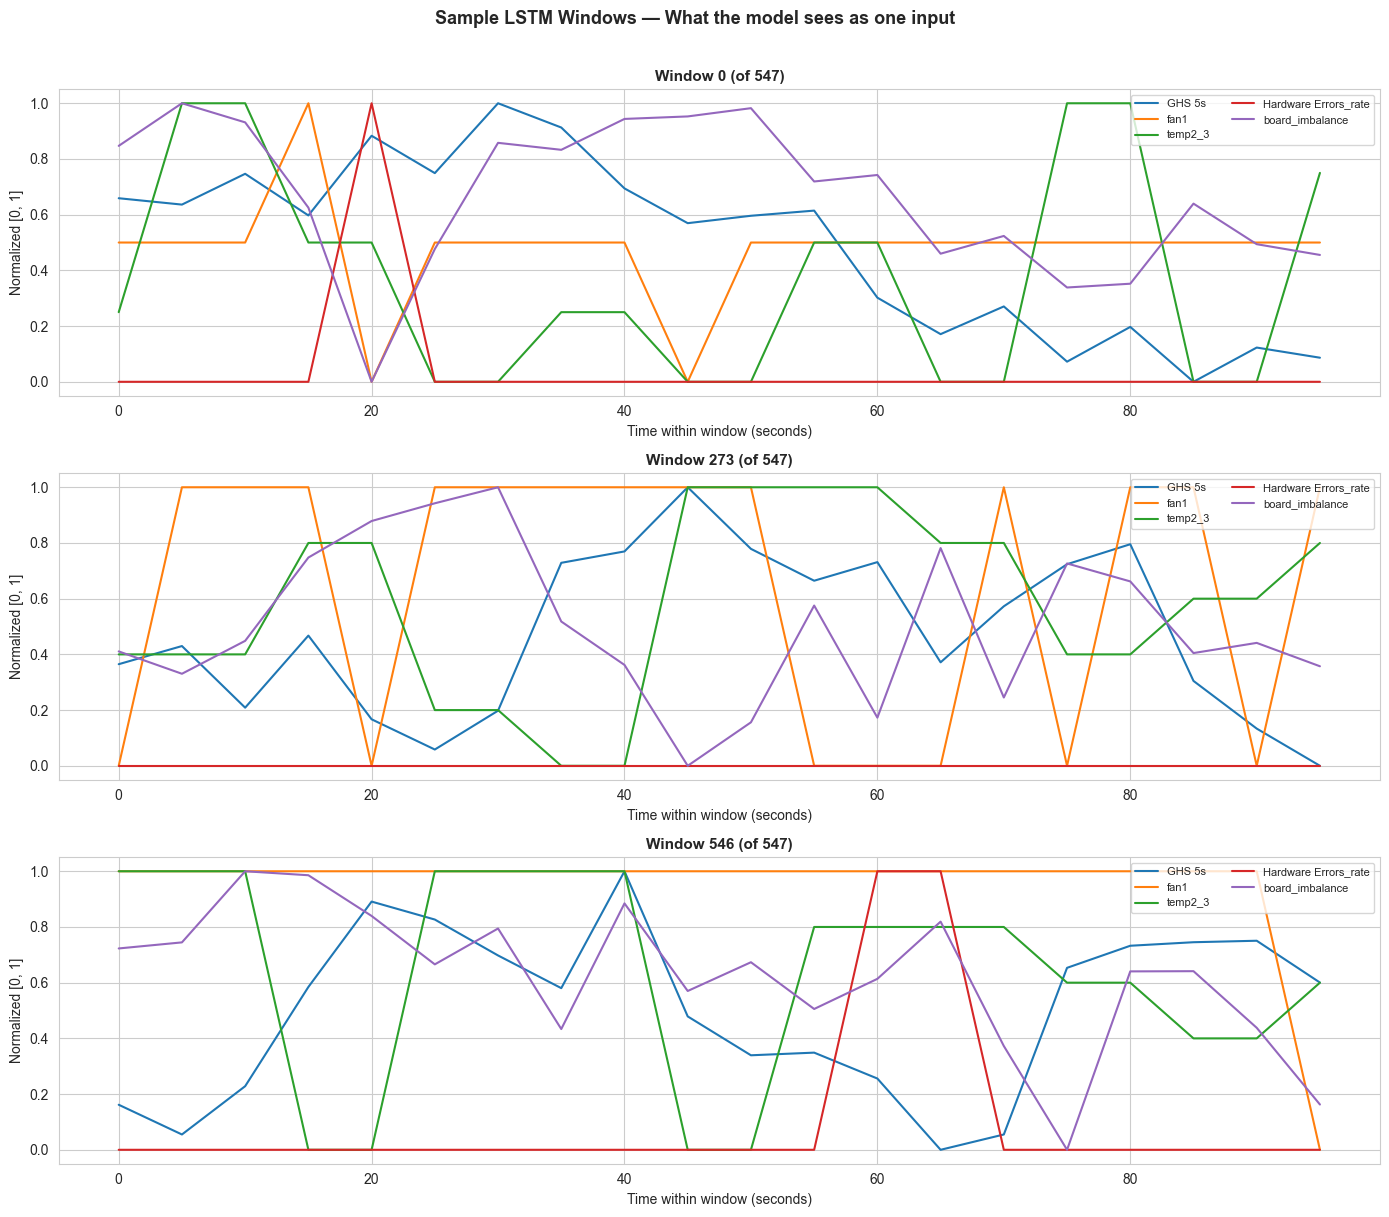

In [15]:
# Visualize a sample window to show what the LSTM sees as one input
sample_indices = [0, n_windows // 2, n_windows - 1]
viz_features = ['GHS 5s', 'fan1', 'temp2_3', 'Hardware Errors_rate', 'board_imbalance']
viz_idx = [FINAL_FEATURES.index(f) for f in viz_features]

fig, axes = plt.subplots(len(sample_indices), 1, figsize=(14, 4 * len(sample_indices)))
timesteps = np.arange(WINDOW_SIZE) * 5  # seconds

for ax_i, win_i in enumerate(sample_indices):
    ax = axes[ax_i]
    window_data = windows[win_i]  # (20, n_features)
    
    for feat_name, feat_col in zip(viz_features, viz_idx):
        # Normalize each feature to [0,1] within the window for visual comparability
        vals = window_data[:, feat_col]
        vmin, vmax = vals.min(), vals.max()
        if vmax > vmin:
            normed = (vals - vmin) / (vmax - vmin)
        else:
            normed = np.zeros_like(vals)
        ax.plot(timesteps, normed, linewidth=1.5, label=f'{feat_name}')
    
    ax.set_title(f'Window {win_i} (of {n_windows})', fontsize=11, fontweight='bold')
    ax.set_ylabel('Normalized [0, 1]')
    ax.legend(loc='upper right', fontsize=8, ncol=2)
    ax.set_xlabel('Time within window (seconds)')

plt.suptitle('Sample LSTM Windows \u2014 What the model sees as one input', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Each subplot shows one window of 20 timesteps (100 seconds). The features are min-max normalized *within each window* purely for visual comparability — the actual LSTM receives raw values. Key things to notice:

- `GHS 5s` (hashrate) shows the fast 5-second oscillation the LSTM needs to learn as "normal jitter"
- `fan1` shows discrete step changes — the LSTM must learn that sudden RPM jumps are normal fan controller behavior, not anomalies
- `Hardware Errors_rate` is mostly zero with occasional spikes of 1 — the LSTM should learn that isolated spikes are normal but sustained bursts are not
- `board_imbalance` is consistently low — a sustained increase would indicate a board-specific problem
- The window at the start, middle, and end of the capture all look similar, confirming the data is stationary after our preprocessing

---
## 11. Final Feature Validation

Before saving, we verify that the processed feature matrix meets all requirements for model training: no nulls, no infinite values, no constant columns, and reasonable value ranges.

In [16]:
feature_df = df_final[FINAL_FEATURES]

print('=== Final Feature Matrix Validation ===')
print(f'Shape: {feature_df.shape}')
print()

# Check for nulls
null_counts = feature_df.isnull().sum()
total_nulls = null_counts.sum()
print(f'Null values: {total_nulls}')
if total_nulls > 0:
    print('  Columns with nulls:')
    for col in null_counts[null_counts > 0].index:
        print(f'    {col}: {null_counts[col]} nulls')

# Check for infinities
inf_counts = np.isinf(feature_df.values).sum()
print(f'Infinite values: {inf_counts}')

# Check for constant columns
stds = feature_df.std()
constant_cols = stds[stds == 0].index.tolist()
print(f'Constant columns: {len(constant_cols)}')
if constant_cols:
    print(f'  {constant_cols}')

# Summary stats
print(f'\nPer-feature summary:')
print(f'{"Feature":30s} {"Mean":>10s} {"Std":>10s} {"Min":>10s} {"Max":>10s} {"Unique":>7s}')
print('-' * 80)
for feat in FINAL_FEATURES:
    s = feature_df[feat]
    print(f'{feat:30s} {s.mean():10.4f} {s.std():10.4f} {s.min():10.4f} {s.max():10.4f} {s.nunique():7d}')

print(f'\n=== VALIDATION {"PASSED" if total_nulls == 0 and inf_counts == 0 and len(constant_cols) == 0 else "FAILED"} ===')

=== Final Feature Matrix Validation ===
Shape: (566, 30)

Null values: 0
Infinite values: 0
Constant columns: 1
  ['temp1']

Per-feature summary:
Feature                              Mean        Std        Min        Max  Unique
--------------------------------------------------------------------------------
GHS 5s                           261.5043     0.5272   259.8870   262.8650     492
Device Rejected%                   5.0372     1.0481     3.5036     8.2687     272
temp1                             39.0000     0.0000    39.0000    39.0000       1
temp3                             38.0053     0.0727    38.0000    39.0000       2
temp4                             37.9187     0.6129    36.0000    39.0000       4
temp2_1                           45.3958     0.4894    45.0000    46.0000       2
temp2_2                           44.0018     0.4888    43.0000    45.0000       3
temp2_3                           44.2350     1.8006    41.0000    47.0000       7
temp2_4                   

---
## 12. Save Outputs

We save two artifacts for use in Session 3:
1. `processed_features.csv` — the full feature matrix with timestamps, for IF training and general use
2. `lstm_windows.npy` — pre-constructed sliding windows, ready for the LSTM Autoencoder

In [17]:
import os
os.makedirs('data', exist_ok=True)

# Save processed features
df_final.to_csv('data/processed_features.csv', index=False)
print(f'Saved: data/processed_features.csv ({df_final.shape})')

# Save LSTM windows
np.save('data/lstm_windows.npy', windows)
print(f'Saved: data/lstm_windows.npy {windows.shape}')

# Save feature names for reference
print(f'\nFeature order ({len(FINAL_FEATURES)}):')
for i, f in enumerate(FINAL_FEATURES):
    print(f'  [{i:2d}] {f}')

Saved: data/processed_features.csv ((566, 31))
Saved: data/lstm_windows.npy (547, 20, 30)

Feature order (30):
  [ 0] GHS 5s
  [ 1] Device Rejected%
  [ 2] temp1
  [ 3] temp3
  [ 4] temp4
  [ 5] temp2_1
  [ 6] temp2_2
  [ 7] temp2_3
  [ 8] temp2_4
  [ 9] fan1
  [10] fan2
  [11] chain_rate1
  [12] chain_rate2
  [13] chain_rate3
  [14] chain_rate4
  [15] Hardware Errors_rate
  [16] chain_hw1_rate
  [17] chain_hw2_rate
  [18] chain_hw3_rate
  [19] chain_dev1
  [20] chain_dev2
  [21] chain_dev3
  [22] chain_dev4
  [23] board_imbalance
  [24] thermal_ratio
  [25] fan_temp_ratio
  [26] chip_pcb_delta1
  [27] chip_pcb_delta2
  [28] chip_pcb_delta3
  [29] chip_pcb_delta4


---
## Summary

This notebook transformed the 23 raw features from the EDA into a 30-feature processed matrix optimized for anomaly detection:

| Step | What Changed | Why |
|------|-------------|-----|
| Startup trim | Removed first 100 readings | `Device Rejected%` startup decay artifact would teach models that 20% rejection is normal |
| Redundancy removal | Dropped `no_matching_work`, `GHS av`, `temp_max` | r=1.000 redundancy, non-stationarity, derived constant |
| Constant post-trim | Dropped `Device Hardware%` | Became all-zero after startup trim — zero variance carries no signal |
| First-differencing | Replaced 4 cumulative counters with rates | ADF test showed non-stationarity; LSTM needs stationary inputs |
| Board deviation | Added `chain_dev1`–`chain_dev4` + `board_imbalance` | Raw hashrates can't distinguish uniform slowdown from single-board failure |
| Thermal ratios | Added `thermal_ratio`, `fan_temp_ratio` | Captures cross-sensor relationships invisible to individual features |
| Temperature deltas | Added `chip_pcb_delta1`–`chip_pcb_delta4` | Cancels ambient drift, isolates chip-level thermal stress |
| Scaling | RobustScaler (median/IQR) | Handles mixed Gaussian/discrete/sparse distributions better than StandardScaler |

All features are non-null, finite, and non-constant. The correlation structure is substantially cleaner than the raw data, with the r=1.000 `Hardware Errors`↔`no_matching_work` pair eliminated and the non-stationary counter trends removed.